In [1]:
import numpy as np
import xcdat as xc
import scipy
import sys
import matplotlib as mpl
import matplotlib.pyplot as plt 
from cdo import *   # python version
import scipy.stats as stats
import os
import glob

sys.path.append('../../functions/')
from lag_linregress import *
from monthly_departures import *
from MCA import *

In [2]:
def svg_plot(da,savepath='',landmask=False,cmap = "RdBu_r",vmin=np.nan,vcenter=np.nan,vmax=np.nan,cbar=False, save=False):
    import matplotlib.pyplot as plt
    import cartopy.crs as ccrs
    import cartopy.feature as cfeature

    # --- 2. Set up the projection ---
    central_lon = 210
    proj = ccrs.Robinson(central_longitude=central_lon)

    fig = plt.figure(figsize=(11, 6))
    ax = plt.axes(projection=proj)


    # --- 3. Plot the data ---
    # transform=ccrs.PlateCarree() tells cartopy your data is in regular lat/lon coords
    if not np.isnan(vmin):
        mesh = ax.pcolormesh(
                da.lon, da.lat, da,
                transform=ccrs.PlateCarree(),
                cmap=cmap,
                shading="auto",
                norm=mpl.colors.TwoSlopeNorm(vmin=vmin,vcenter=vcenter,vmax=vmax)
            )
    elif not np.isnan(vcenter):
        mag = np.nanmax(np.abs(da.data))
        mesh = ax.pcolormesh(
            da.lon, da.lat, da,
            transform=ccrs.PlateCarree(),
            cmap=cmap,
            norm=mpl.colors.TwoSlopeNorm(vmin=-mag,vcenter=vcenter,vmax=mag),
            shading="auto",
        )
    else:
        mesh = ax.pcolormesh(
            da.lon, da.lat, da,
            transform=ccrs.PlateCarree(),
            cmap=cmap,
            shading="auto",
        )

    # --- 4. Add map features ---
    if landmask:
            land = cfeature.NaturalEarthFeature('physical', 'land', '110m', edgecolor='face')
            ax.add_feature(land, facecolor='lightgray')

    ax.coastlines(linewidth=0.8)
    ax.add_feature(cfeature.BORDERS, linewidth=0.3)
    ax.set_global()  # ensures full globe is shown

    # Optional: gridlines
    gl = ax.gridlines(draw_labels=False, linewidth=0.3, color="gray", alpha=0.5)

    # # --- 5. Colorbar ---
    if cbar:
        cbar = plt.colorbar(mesh, ax=ax, orientation="horizontal", pad=0.05, shrink=0.7)
        cbar.set_label("Your variable (units)")

    # ax.set_title(f"Robinson Projection Centered at {central_lon}°E", fontsize=13)

    plt.tight_layout()
    # plt.savefig("robinson_plot.png", dpi=200, bbox_inches="tight")



    # Make figure and axes backgrounds transparent
    fig.patch.set_alpha(0)
    ax.patch.set_alpha(0)

    # Cartopy adds its own background patch for the map outline — clear that too
    # ax.background_patch.set_alpha(0)   # older cartopy versions
    # or, in newer cartopy versions:
    ax.spines['geo'].set_visible(False)  # optional: remove the border/outline too

    # Save as SVG with transparency
    if save:
        plt.savefig(savepath, format="svg", transparent=True, bbox_inches="tight")
    plt.show()

In [3]:
cdo = Cdo()
template_path           = '/scratch/leiff/MCA/data/rlut_mon_CanESM5_historical_r1i1p1f1_g025.nc'

In [4]:
template = xc.open_dataset('/scratch/leiff/MCA/data/template_g025.nc')

In [5]:
filepath_input_era5     = '/rugenstein-archive/senne/data/obs/ERA5/tas_ERA5_194001-202412.nc'
filepath_input_ceres    = '/rugenstein-archive/senne/data/observations/CERES/CERES_EBAF-TOA_Ed4.2.1_Subset_1degx1deg_200003-202604.nc'

In [6]:
# Remapping 
filepath_output_ceres   = '/scratch/leiff/MCA/amip_clean/data/CERES/CERES_net_200003-202604_g025.nc'
filepath_output_era5    = '/scratch/leiff/MCA/amip_clean/data/ERA5/tas_194001-202412_g025.nc'

# cdo.remapcon(template_path,  input =  filepath_input_ceres, output = filepath_output_ceres, options = '-O -s -f nc4c -z zip_4')
# cdo.remapcon(template_path,  input =  filepath_input_era5, output = filepath_output_era5, options = '-O -s -f nc4c -z zip_4')



In [7]:
ERA5    = xc.open_dataset(filepath_output_era5).sel(time=slice('2000-03','2014-12')).rename_vars({
        "t2m": "tas",})
CERES   = xc.open_dataset(filepath_output_ceres).drop_vars(('toa_sw_all_mon','toa_lw_all_mon','toa_sw_clr_c_mon',
        'toa_lw_clr_c_mon','toa_net_clr_c_mon','solar_mon','cldarea_total_daynight_mon','cldpress_total_daynight_mon',
        'cldtemp_total_daynight_mon','cldtau_total_day_mon')).sel(time=slice('2000-03','2014-12')).rename_vars({
        "toa_net_all_mon": "N",})

In [8]:
ERA5

<xarray.Dataset> Size: 7MB
Dimensions:   (time: 178, lat: 72, lon: 144, bnds: 2)
Coordinates:
  * time      (time) object 1kB 2000-03-01 00:00:00 ... 2014-12-01 00:00:00
  * lat       (lat) float64 576B -88.75 -86.25 -83.75 ... 83.75 86.25 88.75
  * lon       (lon) float64 1kB 1.25 3.75 6.25 8.75 ... 351.2 353.8 356.2 358.8
Dimensions without coordinates: bnds
Data variables:
    tas       (time, lat, lon) float32 7MB ...
    lon_bnds  (lon, bnds) float64 2kB 0.0 2.5 2.5 5.0 ... 357.5 357.5 360.0
    lat_bnds  (lat, bnds) float64 1kB -90.0 -87.5 -87.5 -85.0 ... 87.5 87.5 90.0
Attributes:
    CDI:          Climate Data Interface version 2.5.0 (https://mpimet.mpg.de...
    Conventions:  CF-1.6
    history:      Tue Aug 25 16:02:53 2026: cdo -O -s -O -s -f nc4c -z zip_4 ...
    CDO:          Climate Data Operators version 2.5.0 (https://mpimet.mpg.de...

In [9]:
CERES

<xarray.Dataset> Size: 7MB
Dimensions:   (time: 178, lat: 72, lon: 144, bnds: 2)
Coordinates:
  * time      (time) object 1kB 2000-03-15 00:00:00 ... 2014-12-15 00:00:00
  * lat       (lat) float64 576B -88.75 -86.25 -83.75 ... 83.75 86.25 88.75
  * lon       (lon) float64 1kB 1.25 3.75 6.25 8.75 ... 351.2 353.8 356.2 358.8
Dimensions without coordinates: bnds
Data variables:
    N         (time, lat, lon) float32 7MB ...
    lon_bnds  (lon, bnds) float64 2kB 0.0 2.5 2.5 5.0 ... 357.5 357.5 360.0
    lat_bnds  (lat, bnds) float64 1kB -90.0 -87.5 -87.5 -85.0 ... 87.5 87.5 90.0
Attributes:
    CDI:          Climate Data Interface version 2.5.0 (https://mpimet.mpg.de...
    Conventions:  CF-1.4
    institution:  NASA/LaRC (Langley Research Center) Hampton, Va
    title:        CERES EBAF (Energy Balanced and Filled) TOA Fluxes. Monthly...
    comment:      Climatology from 07/2005 to 06/2015
    version:      Edition 4.2.1; Release Date November 25, 2024
    DOI:          10.5067/TERRA-AQUA-NOAA20/CERES/EBAF-TOA_L3B004.2.1
    history:      Tue Aug 25 16:01:22 2026: cdo -O -s -O -s -f nc4c -z zip_4 ...
    CDO:          Climate Data Operators version 2.5.0 (https://mpimet.mpg.de...

In [10]:
ERA5['weights'] = ERA5['tas'][0]*0 + np.cos(np.deg2rad(ERA5.lat))

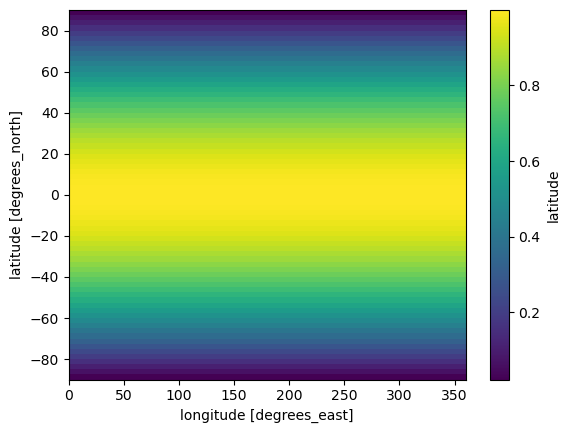

In [11]:
ERA5['weights'].plot()

In [12]:
ERA5['T']   = np.sum(ERA5['tas']*ERA5['weights'],axis=(1,2))/np.sum(ERA5['weights'])
CERES['Ng'] = np.sum(CERES['N']*ERA5['weights'],axis=(1,2))/np.sum(ERA5['weights'])

In [13]:
n_lat       = len(ERA5.lat)
n_lon       = len(ERA5.lon)
n_flat      = n_lat*n_lon
n_time      = len(ERA5.time)
weights_1D  = np.array(ERA5['weights'].data).reshape(n_flat)
print(n_time,n_lat,n_lon,n_flat)

178 72 144 10368


In [14]:
# Move spatial and global N and tas into detrended anomalies
tas_obs = detrend_monthly_fast(np.array(ERA5['tas'].data))
N_obs   = detrend_monthly_fast(np.array(CERES['N'].data))

tas_obs_reshaped    = tas_obs.reshape(n_time,n_flat)
N_obs_reshaped      = N_obs.reshape(n_time,n_flat)

T_obs   = detrend_monthly_fast(np.array(ERA5['T'].data))
Ng_obs  = detrend_monthly_fast(np.array(CERES['Ng'].data))

In [15]:
# anomalies_test = remove_monthly_climatology_fast(np.array(ERA5['tas'].data), start_month=3)

In [16]:
def plot_array(arr):
    template['arr'] = (('lat','lon'), arr)
    svg_plot(template['arr'],cbar=True,vcenter=0)
    template.drop_vars('arr')

In [17]:
covRTi_obs      = MCA_dave(tas_obs_reshaped, Ng_obs, weights_1D, standardized=True).reshape(n_lat,n_lon)
covTRi_obs      = MCA_dave(N_obs_reshaped, T_obs, weights_1D, standardized=True).reshape(n_lat,n_lon)
_,_,regTiRi_obs,_   = lag_linregress_3D(tas_obs,N_obs)


In [50]:
# plot_3_observation_maps

import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from cartopy.util import add_cyclic_point
from pathlib import Path


def plot_3_observation_maps(
    maps,
    lat,
    lon,
    panel_titles,
    *,
    figure_title="Observations",
    colorbar_labels=None,
    cmaps="RdBu_r",
    vlims=None,
    robust_percentile=98,
    number_of_levels=21,
    central_longitude=0,
    savepath=None,
    dpi=200,
):
    """
    Plot three observational maps vertically.

    Parameters
    ----------
    maps
        List of three arrays, each shaped (lat, lon).
    lat, lon
        One-dimensional spatial coordinates.
    panel_titles
        Three panel titles in top-to-bottom order.
    colorbar_labels
        Three colorbar labels. Defaults to blank labels.
    cmaps
        One colormap name or a list of three colormap names.
    vlims
        Three symmetric absolute color limits. Use None for automatic robust
        limits, for example [None, None, None]. A single number applies to all.
    savepath
        Optional output filename.
    """
    if len(maps) != 3:
        raise ValueError(
            f"Expected three maps, received {len(maps)}"
        )

    if len(panel_titles) != 3:
        raise ValueError(
            "panel_titles must contain exactly three titles"
        )

    maps = np.stack(
        [np.asarray(model_map) for model_map in maps],
        axis=0,
    )

    lat = np.asarray(lat)
    lon = np.asarray(lon)

    if maps.shape[1:] != (len(lat), len(lon)):
        raise ValueError(
            f"Map shape {maps.shape[1:]} does not match "
            f"lat/lon lengths {(len(lat), len(lon))}"
        )

    if colorbar_labels is None:
        colorbar_labels = ["", "", ""]

    if len(colorbar_labels) != 3:
        raise ValueError(
            "colorbar_labels must contain exactly three labels"
        )

    if isinstance(cmaps, str):
        cmaps = [cmaps] * 3

    if len(cmaps) != 3:
        raise ValueError(
            "cmaps must be one name or a list of three names"
        )

    if vlims is None:
        vlims = [None, None, None]
    elif np.isscalar(vlims):
        vlims = [float(vlims)] * 3
    else:
        vlims = list(vlims)

    if len(vlims) != 3:
        raise ValueError(
            "vlims must be one number or a list of three values"
        )

    projection = ccrs.Robinson(
        central_longitude=central_longitude
    )

    fig, axes = plt.subplots(
        3,
        1,
        figsize=(12, 11.5),
        subplot_kw={"projection": projection},
        constrained_layout=True,
    )

    for panel_index, ax in enumerate(axes):
        panel_map = maps[panel_index]
        panel_vlim = vlims[panel_index]

        # Derive a robust, symmetric color scale for this diagnostic.
        if panel_vlim is None:
            finite_values = np.abs(
                panel_map[np.isfinite(panel_map)]
            )

            if finite_values.size == 0:
                raise ValueError(
                    f"Panel {panel_index + 1} has no finite values"
                )

            panel_vlim = np.percentile(
                finite_values,
                robust_percentile,
            )

            if panel_vlim == 0:
                panel_vlim = np.max(finite_values)

            if panel_vlim == 0:
                panel_vlim = 1.0

        levels = np.linspace(
            -panel_vlim,
            panel_vlim,
            number_of_levels,
        )

        # Add a cyclic longitude point to remove the map seam.
        if np.isclose(
            abs(lon[-1] - lon[0]),
            360.0,
        ):
            plot_map = panel_map
            plot_lon = lon
        else:
            plot_map, plot_lon = add_cyclic_point(
                panel_map,
                coord=lon,
                axis=-1,
            )

        mappable = ax.contourf(
            plot_lon,
            lat,
            plot_map,
            levels=levels,
            cmap=cmaps[panel_index],
            extend="both",
            transform=ccrs.PlateCarree(),
        )

        ax.set_global()
        ax.coastlines(
            resolution="110m",
            linewidth=0.55,
            color="0.2",
        )

        ax.gridlines(
            linewidth=0.3,
            color="0.35",
            alpha=0.4,
            linestyle=":",
        )

        panel_letter = chr(ord("a") + panel_index)

        ax.set_title(
            f"({panel_letter}) {panel_titles[panel_index]}",
            fontsize=12,
            pad=5,
        )

        colorbar = fig.colorbar(
            mappable,
            ax=ax,
            orientation="horizontal",
            pad=0.035,
            fraction=0.055,
            aspect=35,
            extend="both",
        )

        colorbar.set_label(
            colorbar_labels[panel_index],
            fontsize=10,
        )

        colorbar.ax.tick_params(
            labelsize=9,
        )

    fig.suptitle(
        figure_title,
        fontsize=16,
    )

    if savepath is not None:
        savepath = Path(savepath)
        savepath.parent.mkdir(
            parents=True,
            exist_ok=True,
        )

        fig.savefig(
            savepath,
            dpi=dpi,
            bbox_inches="tight",
        )

        print(f"Saved: {savepath}")

    return fig, axes

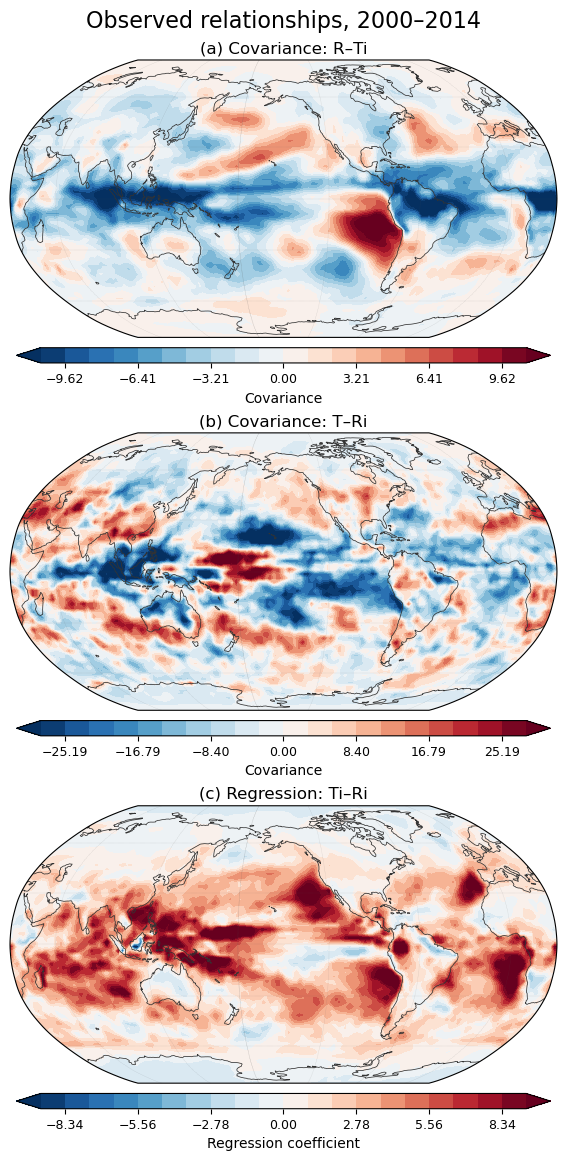

In [ ]:
fig, axes = plot_3_observation_maps(
    maps=[
        covRTi_obs,
        covTRi_obs,
        regTiRi_obs,
    ],
    lat=ERA5.lat,
    lon=ERA5.lon,
    panel_titles=[
        "Covariance: R–Ti",
        "Covariance: T–Ri",
        "Regression: Ti–Ri",
    ],
    colorbar_labels=[
        r"Covariance ($\sigma/\sigma$)",
        r"Covariance ($\sigma/\sigma$)",
        r"Regression coefficient (Wm$^{-2}$/K)",
    ],
    figure_title="Observed relationships, 2000–2014",
    central_longitude=210,
)

In [1]:
## Get model names from data path
from pathlib import Path

data_root = Path("/scratch/leiff/MCA/amip_clean/data/")

amip_hist_models = sorted({
    path.parent.name
    for path in data_root.glob(
        "AMIP/*/"
        "N_Amon_*_amip-hist_combined_187001-201412_g025.nc"
    )
})

amip_piForcing_models = sorted({
    path.parent.name
    for path in data_root.glob(
        "AMIP/*/"
        "N_Amon_*_amip-piForcing_combined_187001-201412_g025.nc"
    )
})

historical_models = sorted({
    path.parent.name
    for path in data_root.glob(
        "HIST/*/"
        "N_Amon_*_historical_combined_187001-201412_g025.nc"
    )
})

In [2]:
# Get number of ensembles for each model
from netCDF4 import Dataset


def ensemble_counts(models, folder, experiment):
    """
    Return ensemble counts in exactly the same order as the model list.
    """
    counts = []

    for model in models:
        matches = list(
            (data_root / folder / model).glob(
                f"N_Amon_{model}_{experiment}_combined_"
                "187001-201412_g025.nc"
            )
        )

        if len(matches) != 1:
            raise RuntimeError(
                f"Expected one N file for {model} / {experiment}, "
                f"found {len(matches)}"
            )

        with Dataset(matches[0], "r") as dataset:
            counts.append(len(dataset.dimensions["member"]))

    return counts


amip_hist_n_ensembles = ensemble_counts(
    amip_hist_models,
    "AMIP",
    "amip-hist",
)

amip_piForcing_n_ensembles = ensemble_counts(
    amip_piForcing_models,
    "AMIP",
    "amip-piForcing",
)

historical_n_ensembles = ensemble_counts(
    historical_models,
    "HIST",
    "historical",
)


In [4]:
import numpy as np
np.save('./data/helper/amip_hist_models.npy',amip_hist_models)
np.save('./data/helper/amip_piForcing_models.npy',amip_piForcing_models)
np.save('./data/helper/historical_models.npy',historical_models)

np.save('./data/helper/amip_hist_n_ensembles.npy',amip_hist_n_ensembles)
np.save('./data/helper/amip_piForcing_n_ensembles.npy',amip_piForcing_n_ensembles)
np.save('./data/helper/historical_n_ensembles.npy',historical_n_ensembles)

In [33]:
print("amip_hist_models =", amip_hist_models)
print("amip_piForcing_models =", amip_piForcing_models)
print("historical_models =", historical_models)

print("amip_hist_n_ensembles =", amip_hist_n_ensembles)
print("amip_piForcing_n_ensembles =", amip_piForcing_n_ensembles)
print("historical_n_ensembles =", historical_n_ensembles)

n_amip_hist         = len(amip_hist_models)
n_amip_piForcing    = len(amip_piForcing_models)
n_historical        = len(historical_models)


amip_hist_models = ['BCC-CSM2-MR', 'CAMS-CSM1-0', 'CESM2', 'CIESM', 'CNRM-CM6-1', 'CNRM-CM6-1-HR', 'CNRM-ESM2-1', 'CanESM5', 'FGOALS-f3-L', 'FGOALS-g3', 'FIO-ESM-2-0', 'IITM-ESM', 'IPSL-CM6A-LR', 'MIROC6', 'MRI-ESM2-0', 'TaiESM1']
amip_piForcing_models = ['CESM2', 'CNRM-CM6-1', 'CanESM5', 'HadGEM3-GC31-LL', 'IPSL-CM6A-LR', 'MIROC6', 'MRI-ESM2-0', 'TaiESM1']
historical_models = ['ACCESS-CM2', 'ACCESS-ESM1-5', 'AWI-CM-1-1-MR', 'AWI-ESM-1-1-LR', 'BCC-CSM2-MR', 'BCC-ESM1', 'CAMS-CSM1-0', 'CAS-ESM2-0', 'CESM2', 'CESM2-FV2', 'CESM2-WACCM', 'CESM2-WACCM-FV2', 'CIESM', 'CMCC-CM2-HR4', 'CMCC-CM2-SR5', 'CMCC-ESM2', 'CNRM-CM6-1', 'CNRM-CM6-1-HR', 'CNRM-ESM2-1', 'CanESM5', 'CanESM5-CanOE', 'E3SM-1-0', 'E3SM-1-1', 'E3SM-1-1-ECA', 'EC-Earth3', 'EC-Earth3-AerChem', 'EC-Earth3-Veg', 'EC-Earth3-Veg-LR', 'FGOALS-f3-L', 'FGOALS-g3', 'FIO-ESM-2-0', 'GISS-E2-1-G', 'GISS-E2-1-G-CC', 'GISS-E2-1-H', 'IITM-ESM', 'INM-CM4-8', 'INM-CM5-0', 'IPSL-CM5A2-INCA', 'IPSL-CM6A-LR', 'IPSL-CM6A-LR-INCA', 'KACE-1-0-G', 'KI

First experiment: AMIP-hist

In [45]:
# 16-panel plotting script

import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from cartopy.util import add_cyclic_point
from pathlib import Path


def plot_16_model_maps(
    maps,
    model_names,
    lat,
    lon,
    *,
    title="",
    colorbar_label="",
    cmap="RdBu_r",
    vlim=None,
    robust_percentile=98,
    number_of_levels=21,
    central_longitude=210,
    savepath=None,
    dpi=200,
):
    """
    Plot up to 16 model maps on a shared 4x4 global-map figure.

    Parameters
    ----------
    maps
        Array with shape (model, lat, lon).
    model_names
        Model names in the same order as maps.
    lat, lon
        One-dimensional spatial coordinates.
    vlim
        Absolute color limit. If None, it is calculated robustly from all
        panels using robust_percentile.
    savepath
        Optional output path, such as "./figures/covRTi_amip_hist.png".

    Returns
    -------
    fig, axes
        Matplotlib figure and flattened axes array.
    """
    maps = np.asarray(maps)
    lat = np.asarray(lat)
    lon = np.asarray(lon)
    model_names = list(model_names)

    if maps.ndim != 3:
        raise ValueError(
            f"maps has shape {maps.shape}; "
            "expected (model, lat, lon)"
        )

    if maps.shape[0] != len(model_names):
        raise ValueError(
            f"There are {maps.shape[0]} maps but "
            f"{len(model_names)} model names"
        )

    if len(model_names) > 16:
        raise ValueError(
            "This function supports at most 16 models"
        )

    if maps.shape[1:] != (len(lat), len(lon)):
        raise ValueError(
            f"Map shape {maps.shape[1:]} does not match "
            f"lat/lon lengths {(len(lat), len(lon))}"
        )

    # Use one symmetric color scale across all models.
    if vlim is None:
        finite_values = np.abs(maps[np.isfinite(maps)])

        if finite_values.size == 0:
            raise ValueError("The maps contain no finite values")

        vlim = np.percentile(
            finite_values,
            robust_percentile,
        )

        if vlim == 0:
            vlim = np.max(finite_values)

        if vlim == 0:
            vlim = 1.0

    levels = np.linspace(
        -vlim,
        vlim,
        number_of_levels,
    )

    projection = ccrs.Robinson(
        central_longitude=central_longitude
    )

    fig, axes = plt.subplots(
        4,
        4,
        figsize=(17, 10.5),
        subplot_kw={"projection": projection},
    )

    axes = np.asarray(axes).ravel()
    mappable = None

    for model_index, ax in enumerate(axes):
        if model_index >= len(model_names):
            ax.set_visible(False)
            continue

        model_map = maps[model_index]

        # Close the longitude seam unless the coordinate already includes it.
        if np.isclose(
            abs(lon[-1] - lon[0]),
            360.0,
        ):
            plot_map = model_map
            plot_lon = lon
        else:
            plot_map, plot_lon = add_cyclic_point(
                model_map,
                coord=lon,
                axis=-1,
            )

        mappable = ax.contourf(
            plot_lon,
            lat,
            plot_map,
            levels=levels,
            cmap=cmap,
            extend="both",
            transform=ccrs.PlateCarree(),
        )

        ax.set_global()
        ax.coastlines(
            resolution="110m",
            linewidth=0.5,
            color="0.2",
        )

        ax.gridlines(
            linewidth=0.3,
            color="0.35",
            alpha=0.4,
            linestyle=":",
        )

        ax.set_title(
            f"{model_index + 1}. {model_names[model_index]}",
            fontsize=10,
            pad=4,
        )

    fig.suptitle(
        title,
        fontsize=16,
        y=0.965,
    )

    fig.subplots_adjust(
        left=0.02,
        right=0.98,
        top=0.92,
        bottom=0.105,
        wspace=0.025,
        hspace=0.10,
    )

    colorbar_axis = fig.add_axes(
        [0.22, 0.045, 0.56, 0.025]
    )

    colorbar = fig.colorbar(
        mappable,
        cax=colorbar_axis,
        orientation="horizontal",
        extend="both",
    )

    colorbar.set_label(
        colorbar_label,
        fontsize=11,
    )
    colorbar.ax.tick_params(
        labelsize=9,
    )

    if savepath is not None:
        savepath = Path(savepath)
        savepath.parent.mkdir(
            parents=True,
            exist_ok=True,
        )

        fig.savefig(
            savepath,
            dpi=dpi,
            bbox_inches="tight",
        )

        print(f"Saved: {savepath}")

    return fig, axes

In [22]:
## Cell 1: AMIP-hist, calculate the three maps for all models and ens members 
'''
import xarray as xr
from pathlib import Path

covRTi_amip_hist   = {}
covTRi_amip_hist   = {}
regTiRi_amip_hist  = {}



data_root = Path(
    "/scratch/leiff/MCA/amip_clean/data"
)

for m,model in enumerate(amip_hist_models):
    path_N = (
        data_root
        / "AMIP"
        / model
        / (
            f"N_Amon_{model}_amip-hist_combined_"
            "187001-201412_g025.nc"
        )
    )
    path_T = (
        data_root
        / "AMIP"
        / model
        / (
            f"tas_Amon_{model}_amip-hist_combined_"
            "187001-201412_g025.nc"
        )
    )

    member_covRTi   = []
    member_covTRi   = []
    member_regTiRi  = []

    ## Need to open and process with members in mind
    T_ds        = xc.open_dataset(path_T).sel(time=slice('2000-03','2014-12'))
    N_ds        = xc.open_dataset(path_N).sel(time=slice('2000-03','2014-12'))

    T_ds['T']   = np.sum(T_ds['tas']*ERA5['weights'],axis=(2,3))/np.sum(ERA5['weights'])
    N_ds['Ng']  = np.sum(N_ds['N']*ERA5['weights'],axis=(2,3))/np.sum(ERA5['weights'])

    # display(T_ds)
    # display(N_ds)


    for e in np.arange(amip_hist_n_ensembles[m]):
        print(model)
        print(e)


        # Move spatial and global N and tas into detrended anomalies
        tas_here = detrend_monthly_fast(np.array(T_ds['tas'].data)[e])
        N_here   = detrend_monthly_fast(np.array(N_ds['N'].data)[e])

        tas_here_reshaped    = tas_here.reshape(n_time,n_flat)
        N_here_reshaped      = N_here.reshape(n_time,n_flat)

        T_here   = detrend_monthly_fast(np.array(T_ds['T'].data)[e])
        Ng_here  = detrend_monthly_fast(np.array(N_ds['Ng'].data)[e])

        # print(tas_here_reshaped.shape)
        # print(Ng_here.shape)
        # kill
        
        covRTi_here             = MCA_dave(tas_here_reshaped, Ng_here, weights_1D, standardized=True).reshape(n_lat,n_lon)
        covTRi_here             = MCA_dave(N_here_reshaped, T_here, weights_1D, standardized=True).reshape(n_lat,n_lon)
        _,_,regTiRi_here,_      = lag_linregress_3D(tas_here,N_here)
        
        member_covRTi.append(covRTi_here)
        member_covTRi.append(covTRi_here)
        member_regTiRi.append(regTiRi_here)

    # Shape: (number_of_members, lat, lon)
    covRTi_amip_hist[model] = np.stack(
        member_covRTi,
        axis=0,
    )

    covTRi_amip_hist[model] = np.stack(
        member_covTRi,
        axis=0,
    )

    regTiRi_amip_hist[model] = np.stack(
        member_regTiRi,
        axis=0,
    )
  ''' 

'\nimport xarray as xr\nfrom pathlib import Path\n\ncovRTi_amip_hist   = {}\ncovTRi_amip_hist   = {}\nregTiRi_amip_hist  = {}\n\n\n\ndata_root = Path(\n    "/scratch/leiff/MCA/amip_clean/data"\n)\n\nfor m,model in enumerate(amip_hist_models):\n    path_N = (\n        data_root\n        / "AMIP"\n        / model\n        / (\n            f"N_Amon_{model}_amip-hist_combined_"\n            "187001-201412_g025.nc"\n        )\n    )\n    path_T = (\n        data_root\n        / "AMIP"\n        / model\n        / (\n            f"tas_Amon_{model}_amip-hist_combined_"\n            "187001-201412_g025.nc"\n        )\n    )\n\n    member_covRTi   = []\n    member_covTRi   = []\n    member_regTiRi  = []\n\n    ## Need to open and process with members in mind\n    T_ds        = xc.open_dataset(path_T).sel(time=slice(\'2000-03\',\'2014-12\'))\n    N_ds        = xc.open_dataset(path_N).sel(time=slice(\'2000-03\',\'2014-12\'))\n\n    T_ds[\'T\']   = np.sum(T_ds[\'tas\']*ERA5[\'weights\'],axis=(2,3))

In [23]:
#  Cell 2: AMIP-hist, Save/Load AMIP-hist

# np.save("./data/maps_2000_2014/covRTi_amip_hist.npy",covRTi_amip_hist)
# np.save("./data/maps_2000_2014/covTRi_amip_hist.npy",covTRi_amip_hist)
# np.save("./data/maps_2000_2014/regTiRi_amip_hist.npy",regTiRi_amip_hist)


covRTi_amip_hist    = np.load("./data/maps_2000_2014/covRTi_amip_hist.npy",allow_pickle=True).item()
covTRi_amip_hist    = np.load("./data/maps_2000_2014/covTRi_amip_hist.npy",allow_pickle=True).item()
regTiRi_amip_hist   = np.load("./data/maps_2000_2014/regTiRi_amip_hist.npy",allow_pickle=True).item()


In [39]:
# Cell 3: AMIP-hist, Calculate ens means for each model and multimodel means for each of the 3 maps
covRTi_amip_hist_ensmeans   = np.zeros((n_amip_hist,n_lat,n_lon))
covTRi_amip_hist_ensmeans   = np.zeros((n_amip_hist,n_lat,n_lon))
regTiRi_amip_hist_ensmeans  = np.zeros((n_amip_hist,n_lat,n_lon))

for i in np.arange(n_amip_hist): # i is models
    covRTi_amip_hist_ensmeans[i]        = np.mean(covRTi_amip_hist[amip_hist_models[i]],axis=0)
    covTRi_amip_hist_ensmeans[i]        = np.mean(covTRi_amip_hist[amip_hist_models[i]],axis=0)
    regTiRi_amip_hist_ensmeans[i]       = np.mean(regTiRi_amip_hist[amip_hist_models[i]],axis=0)

covRTi_amip_hist_MMM   = np.mean(covRTi_amip_hist_ensmeans,axis=0)
covTRi_amip_hist_MMM   = np.mean(covTRi_amip_hist_ensmeans,axis=0)
regTiRi_amip_hist_MMM  = np.mean(regTiRi_amip_hist_ensmeans,axis=0)




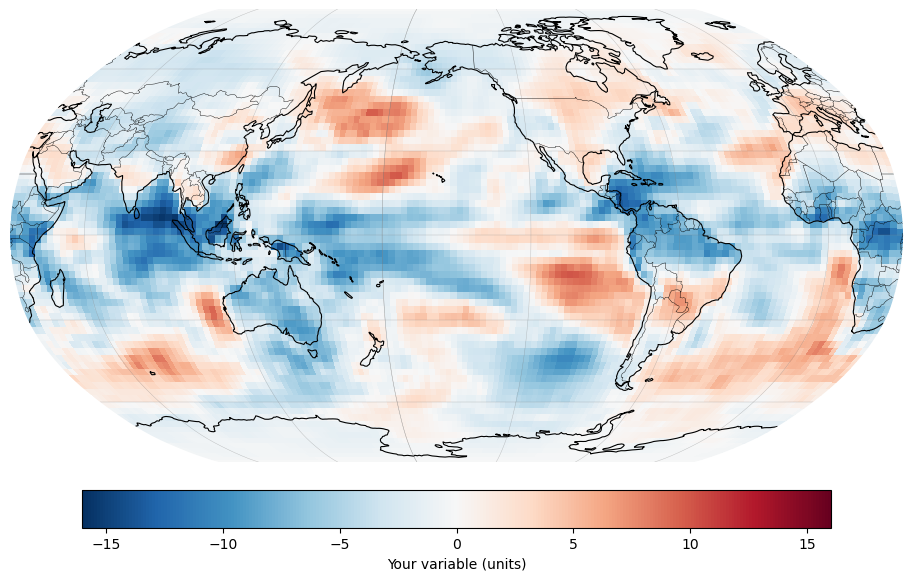

In [49]:
plot_array(covRTi_amip_hist_ensmeans[0])

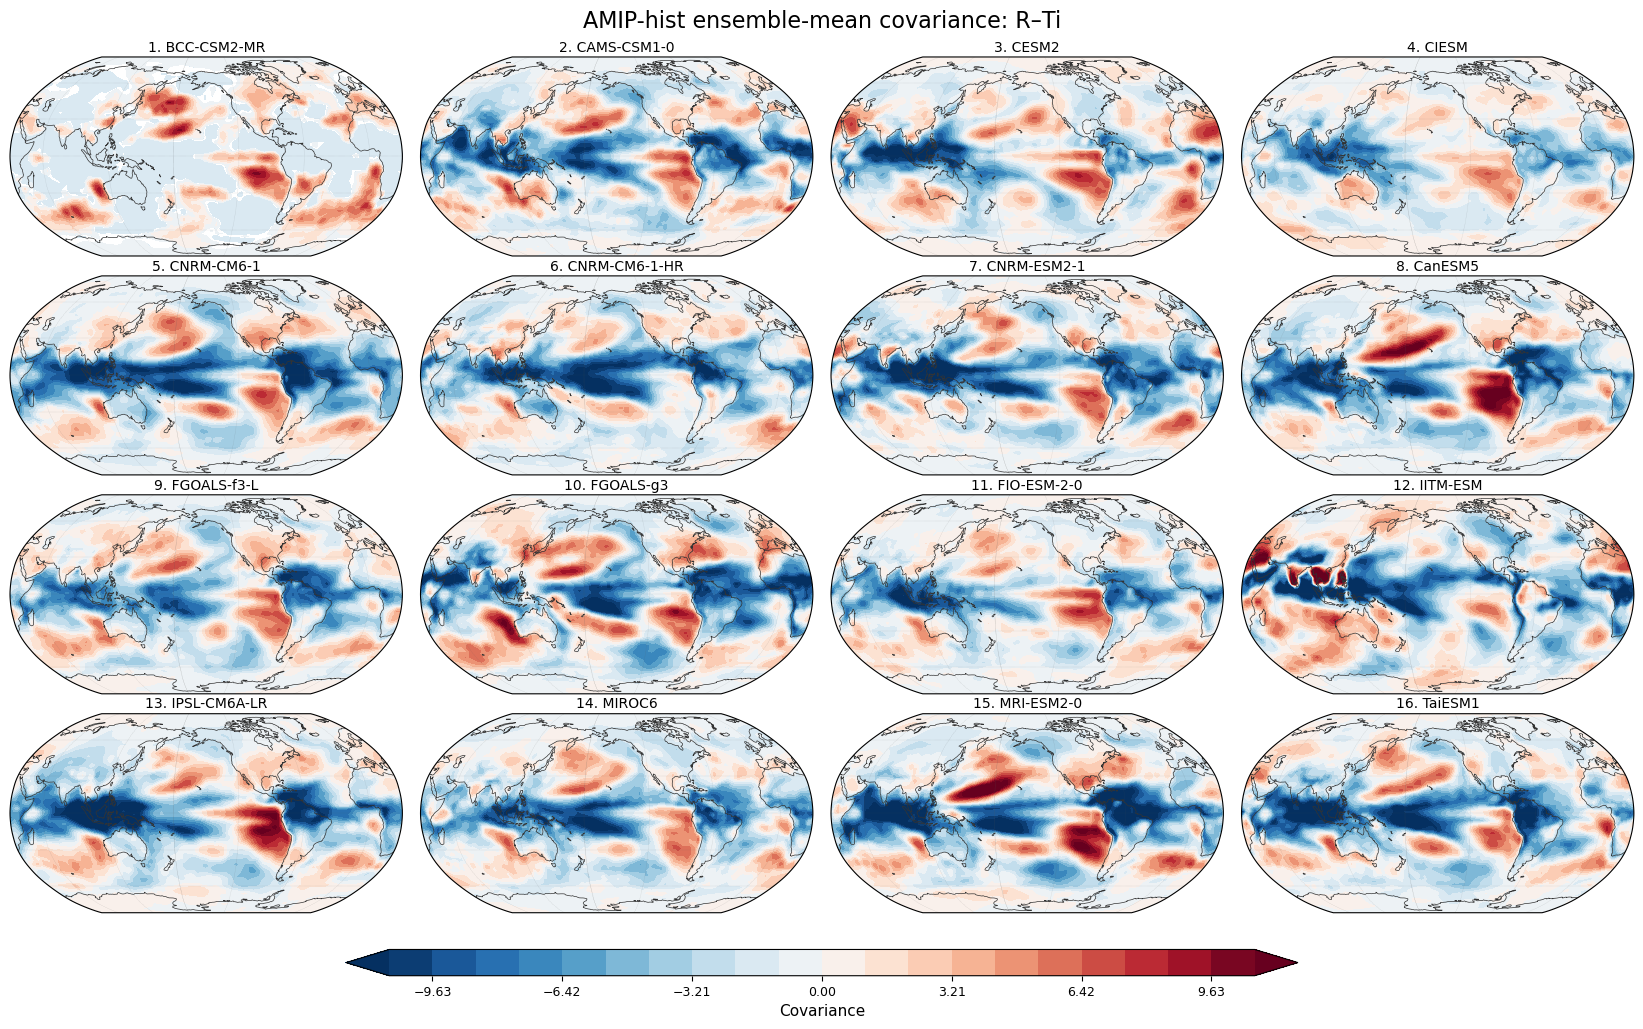

In [46]:
fig, axes = plot_16_model_maps(
    covRTi_amip_hist_ensmeans,
    amip_hist_models,
    ERA5.lat,
    ERA5.lon,
    title="AMIP-hist ensemble-mean covariance: R–Ti",
    colorbar_label="Covariance",
)

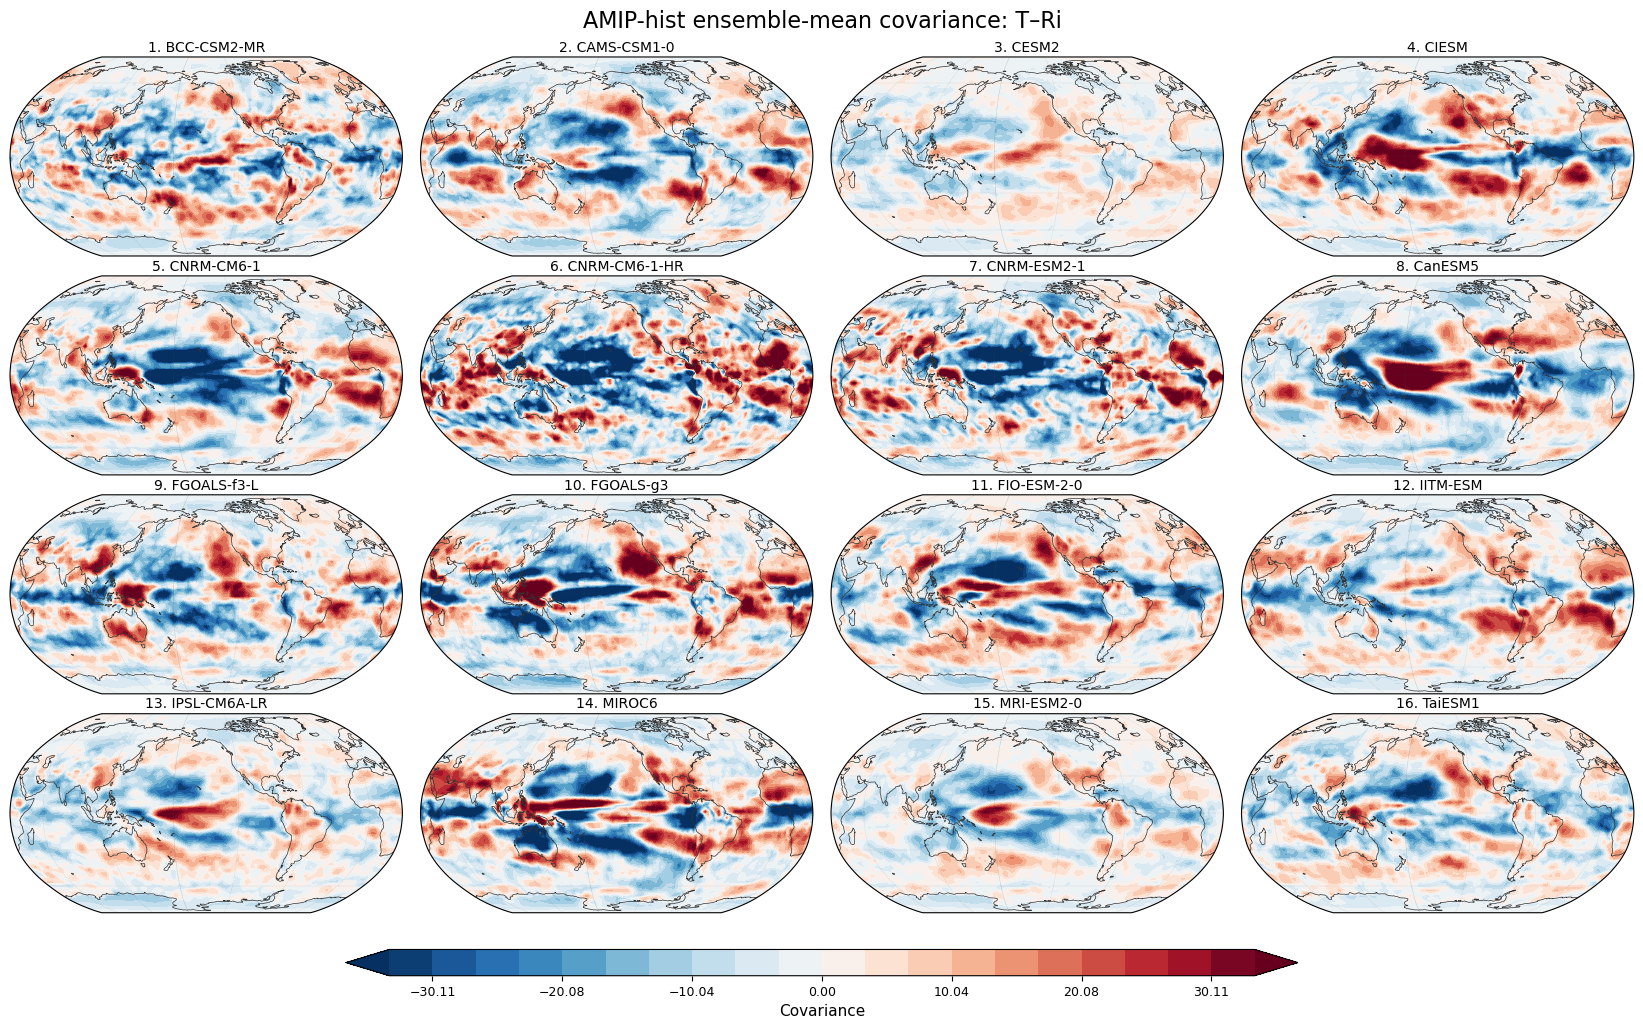

In [47]:
fig, axes = plot_16_model_maps(
    covTRi_amip_hist_ensmeans,
    amip_hist_models,
    ERA5.lat,
    ERA5.lon,
    title="AMIP-hist ensemble-mean covariance: T–Ri",
    colorbar_label="Covariance",
)

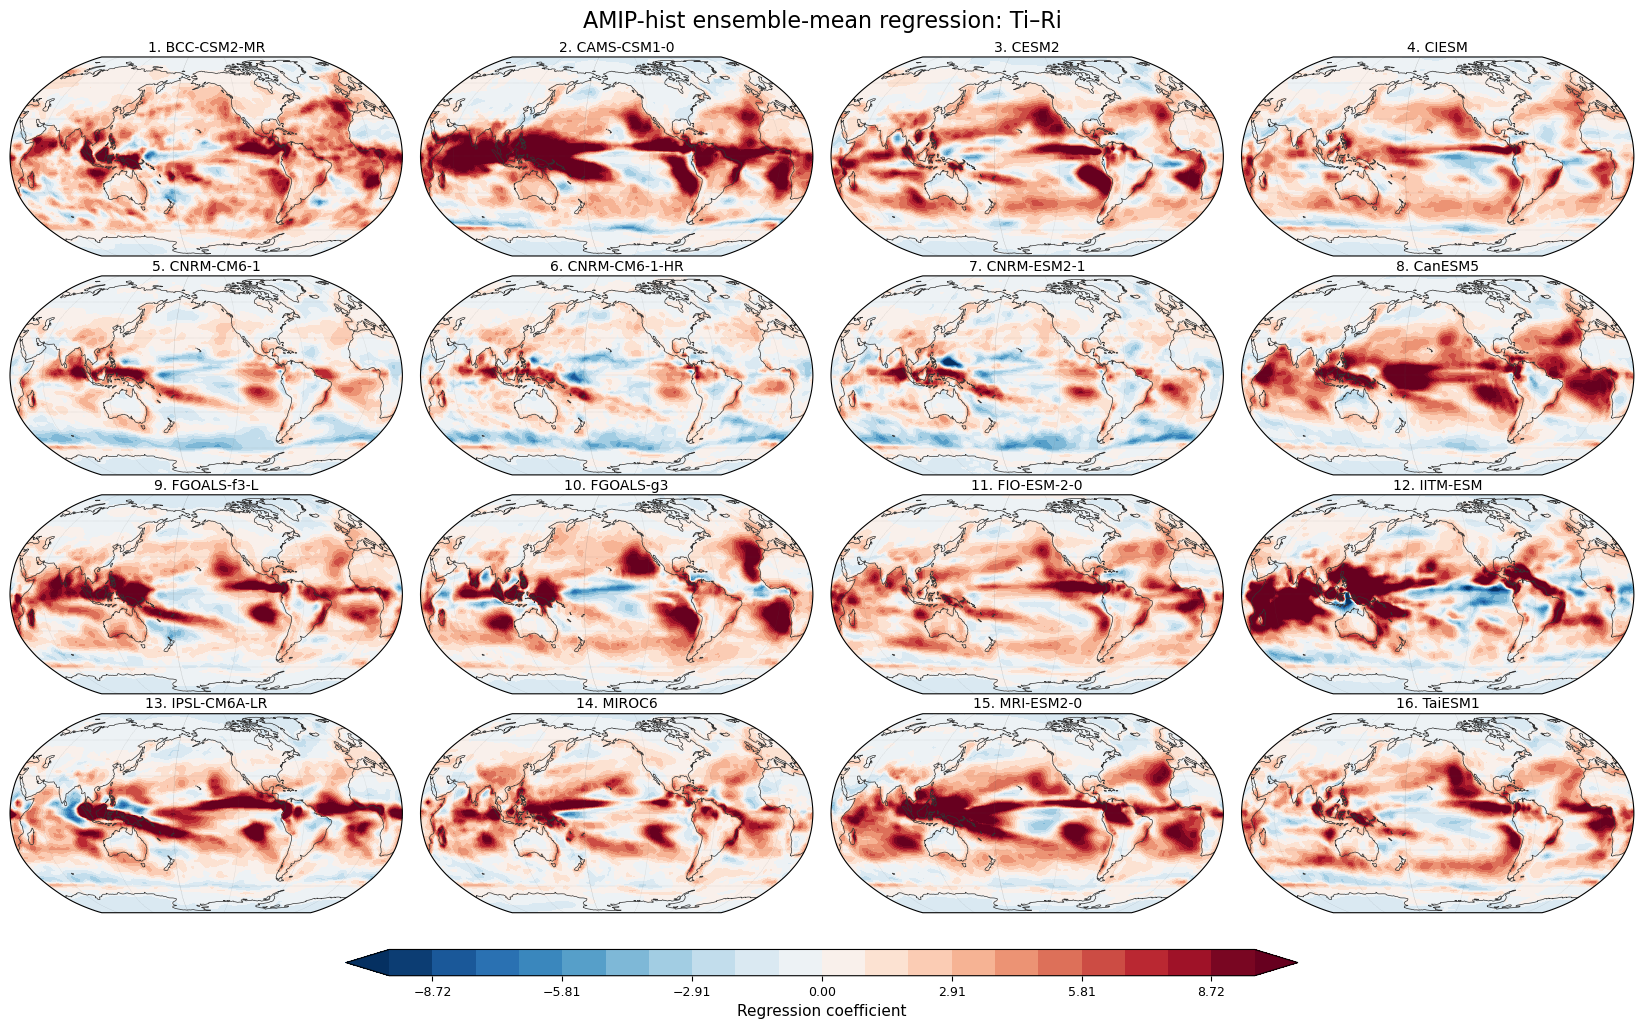

In [48]:
fig, axes = plot_16_model_maps(
    regTiRi_amip_hist_ensmeans,
    amip_hist_models,
    ERA5.lat,
    ERA5.lon,
    title="AMIP-hist ensemble-mean regression: Ti–Ri",
    colorbar_label="Regression coefficient",
)

In [34]:
covRTi_amip_hist[amip_hist_models[1]]

array([[[ 4.82146241e-02,  4.60474440e-02,  4.35343433e-02, ...,
          4.76550069e-02,  5.12220318e-02,  4.91190020e-02],
        [ 2.24481822e-01,  2.31874186e-01,  2.34018833e-01, ...,
          2.10473711e-01,  2.18685496e-01,  2.22301764e-01],
        [ 3.83035998e-01,  3.90568407e-01,  4.01938803e-01, ...,
          3.78146871e-01,  3.76550863e-01,  3.79707232e-01],
        ...,
        [-7.92433395e-01, -7.89763147e-01, -7.96107364e-01, ...,
         -7.28756776e-01, -7.72624585e-01, -7.79075678e-01],
        [-4.79959682e-01, -4.80135968e-01, -4.80675626e-01, ...,
         -4.66210574e-01, -4.74113675e-01, -4.76661603e-01],
        [-1.78863251e-01, -1.79585643e-01, -1.79320953e-01, ...,
         -1.81539154e-01, -1.83564033e-01, -1.81122082e-01]],

       [[-3.09356265e-02, -3.35158640e-02, -3.38388599e-02, ...,
         -2.47243443e-02, -2.60059937e-02, -2.81002646e-02],
        [-6.69499725e-03, -7.93628405e-03, -1.24518356e-02, ...,
         -5.65538252e-03, -3.06263994e

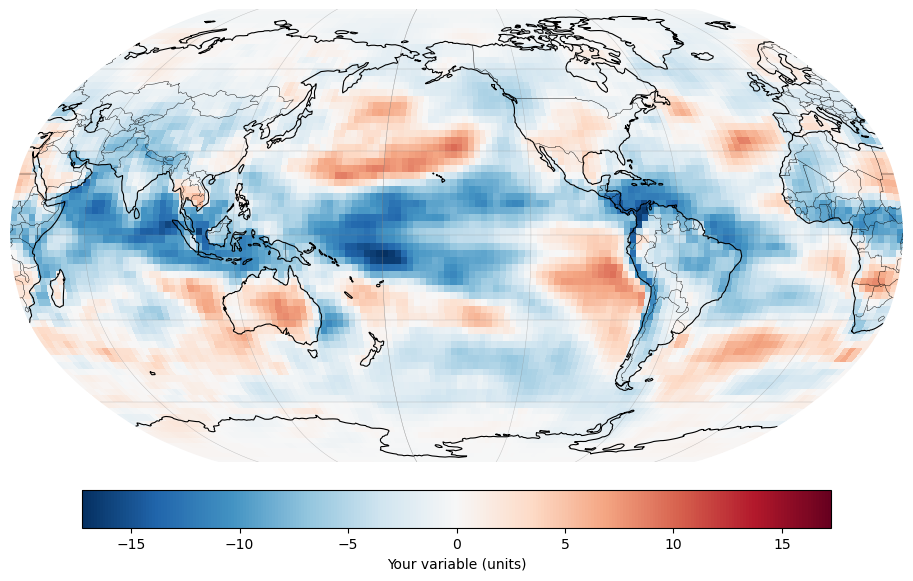

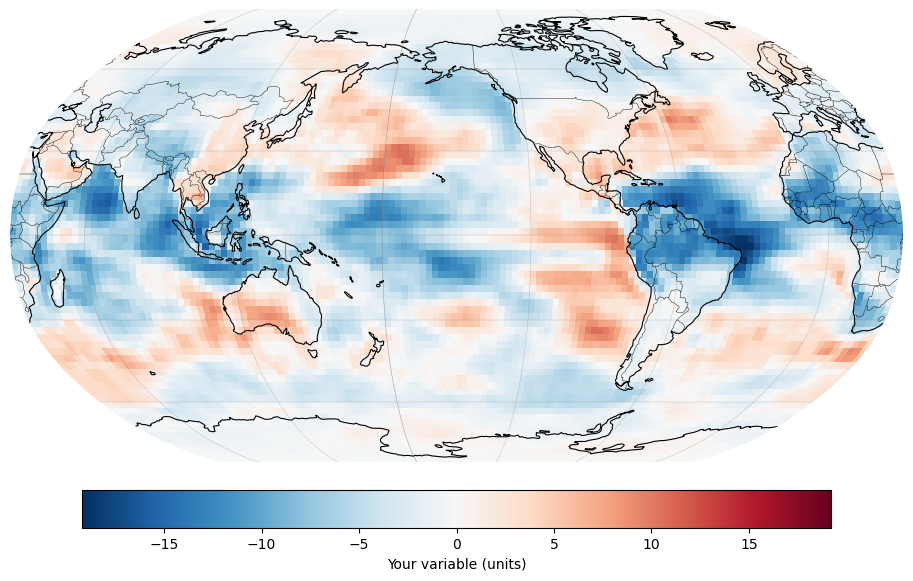

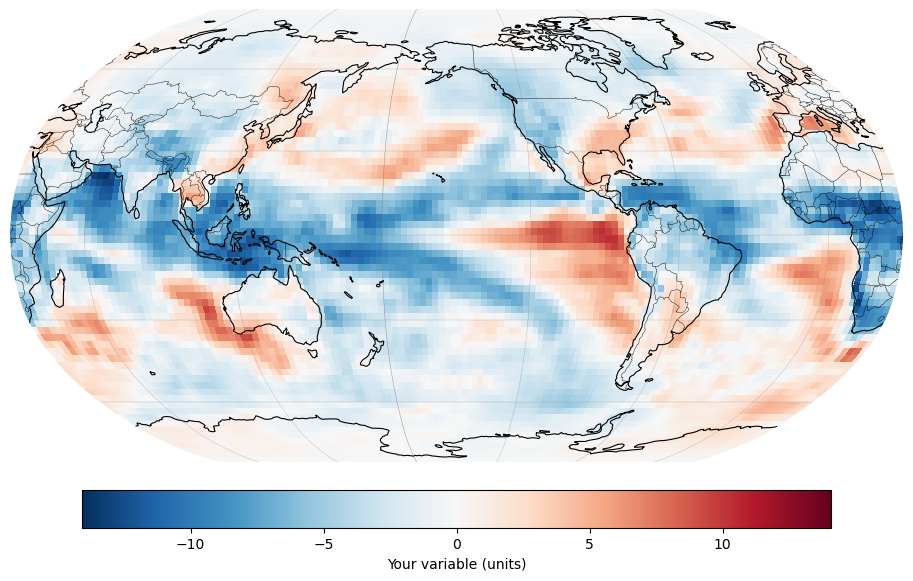

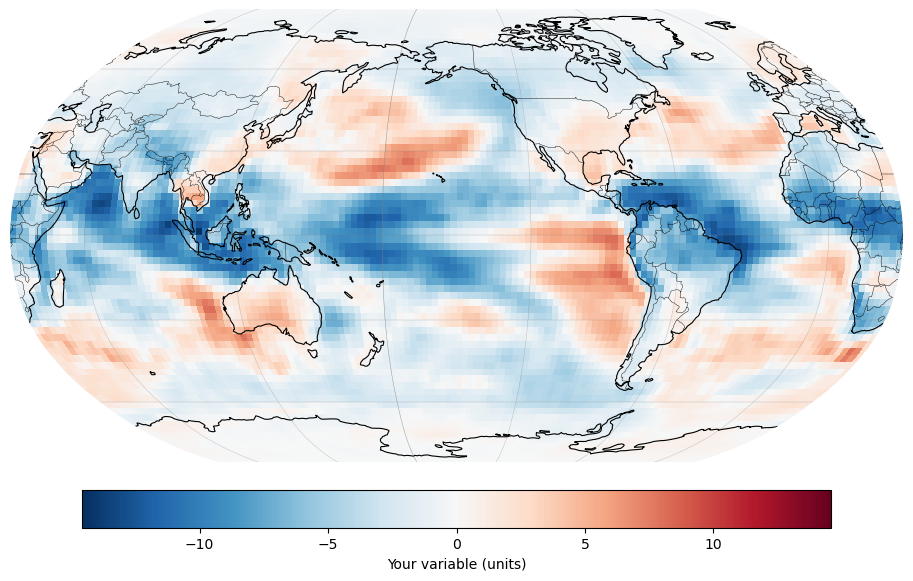

In [37]:
plot_array(covRTi_amip_hist[amip_hist_models[1]][0])
plot_array(covRTi_amip_hist[amip_hist_models[1]][1])
plot_array(covRTi_amip_hist[amip_hist_models[1]][2])
plot_array()